# Анализ данных по аренде велосипедов

Представьте, что вы работаете аналитиком в компании, которая занимается арендой велосипедов.

Коллега из офиса в Лондоне прислал вам данные за два года:  
с `4 января 2015` по `3 января 2017`.

Вам предстоит изучить:

- динамику числа аренд
- наличие связи с погодными условиями
- наличие связи с выходными
- несколько аномалий на графике

---

# Задания

## 1. Первичный анализ данных

Загрузите данные и проверьте:

- число наблюдений и столбцов
- наличие пропусков
- корректность типов данных

При необходимости приведите переменные к нужным типам.

## 2. Динамика числа поездок

Постройте график по числу поездок по дате и времени.

## 3. Агрегация по дням

Преобразуйте данные и посчитайте число поездок по дням.

Визуализируйте результат.

## 4. Скользящее среднее

Используйте агрегированные данные по дням и посчитайте скользящее среднее с окном `3`.

В качестве ответа укажите полученное число аренд за `2015-07-09`, округлив значение до целого.

## 5. Разница между наблюдаемыми и сглаженными значениями

Посчитайте разницу между наблюдаемыми значениями и значениями, подсчитанными с помощью скользящего среднего.

Далее найдите стандартное отклонение.

## 6. Доверительный интервал

Определите границы `99%` доверительного интервала.

Добавьте данную информацию в датафрейм.

## 7. Аномально высокие значения

Изучите аномально высокие значения и укажите день, когда число аренд было наибольшим.

Найдите причину данной аномалии.

## 8. Аномально низкие значения

Изучите аномально низкие значения и найдите день с наименьшим числом аренд.

Найдите причину данной аномалии.

---

# Описание данных

| Поле | Описание |
|---|---|
| `timestamp` | дата и время, точность до часа |
| `cnt` | количество аренд велосипедов за этот час |
| `t1` | температура, °C |
| `t2` | температура «ощущается как», °C |
| `hum` | влажность, % |
| `wind_speed` | скорость ветра, км/ч |
| `weather_code` | погодные условия |
| `isholiday` | является ли день праздником |
| `isweekend` | является ли день выходным |
| `season` | метеорологический сезон |

---

# Расшифровка `weather_code`

| Код | Погодные условия |
|---|---|
| `1` | ясно (`SKC`) |
| `2` | преимущественно ясно / встречаются отдельные облака (`SCT`) |
| `3` | облачно / значительные облака (`BKN`) |
| `4` | пасмурно (`OVC`) |
| `7` | небольшой дождь / light rain shower / light rain |
| `10` | дождь с грозой |
| `26` | снегопад |
| `94` | ледяной туман |

---

# Расшифровка бинарных переменных

| Поле | Значение |
|---|---|
| `isholiday` | `1` — праздник, `0` — нет |
| `isweekend` | `1` — выходной, `0` — нет |

---

# Расшифровка `season`

| Код | Сезон |
|---|---|
| `0` | весна |
| `1` | лето |
| `2` | осень |
| `3` | зима |

In [1]:
import pandas as pd

In [2]:
london = pd.read_csv('london.csv')

In [3]:
london.head()

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0


In [4]:
london.shape

(17414, 10)

In [6]:
london.dtypes

timestamp        object
cnt               int64
t1              float64
t2              float64
hum             float64
wind_speed      float64
weather_code    float64
is_holiday      float64
is_weekend      float64
season          float64
dtype: object

In [9]:
london.timestamp = pd.to_datetime(london.timestamp)

In [10]:
london.dtypes

timestamp       datetime64[ns]
cnt                      int64
t1                     float64
t2                     float64
hum                    float64
wind_speed             float64
weather_code           float64
is_holiday             float64
is_weekend             float64
season                 float64
dtype: object

In [11]:
london.head()

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0


In [12]:
london.isna().sum()

timestamp       0
cnt             0
t1              0
t2              0
hum             0
wind_speed      0
weather_code    0
is_holiday      0
is_weekend      0
season          0
dtype: int64

## Задание 2

Для начала попробуем посмотреть на число поездок по датам и времени. Постройте линейный график с помощью sns.lineplot(), где:

по оси x – дата (timestamp)
по оси y – число поездок (cnt)

In [13]:
import seaborn as sns

<Axes: xlabel='timestamp', ylabel='cnt'>

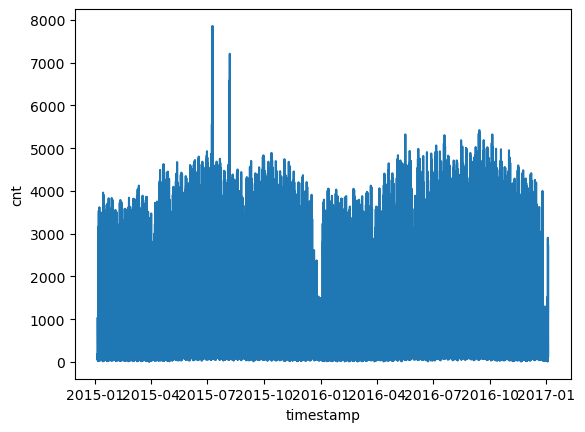

In [15]:
sns.lineplot(data = london, x = 'timestamp', y = 'cnt', estimator=None)

## Задание 3

Отлично! Предположим, что данные действительно нужно немного преобразовать. В этом нам поможет метод .resample() (про него также можно глянуть здесь).

Этот метод позволяет сгруппировать данные по единице времени и агрегировать другой столбец (фактически это .groupby() для задач, связанных с временными промежутками). Так можно рассчитать показатели, например, за весь день или месяц, имея данные с точностью до минут. 
Суммируйте число поездок по дням с помощью .resample() и визуализируйте результат. Что вы можете сказать о полученном графике?


In [20]:
cnt_by_day = london.resample(rule = 'D', on = 'timestamp').cnt.sum().reset_index()

<Axes: xlabel='timestamp', ylabel='cnt'>

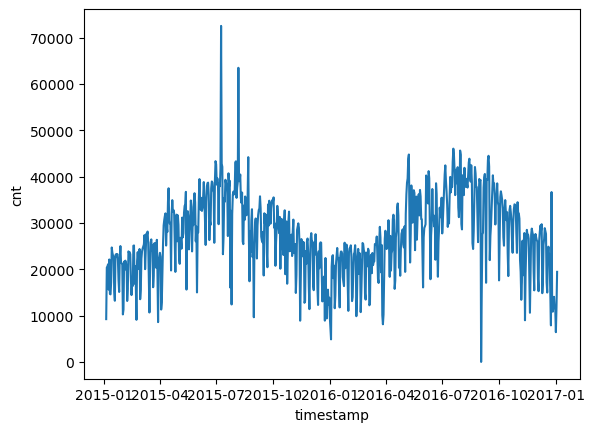

In [21]:
sns.lineplot(data = cnt_by_day, x = 'timestamp', y = 'cnt', estimator=None)

## Задание 4

Итак, вы обнаружили на графике некоторые скачки. Давайте проверим, что же могло произойти в те дни - и насколько эти изменения для нас неожиданны 🤔. Для этого мы попробуем построить доверительный интервал вокруг данных - всё, что выпадает за его пределы, будет считаться аномалией, и на отдельные из них мы потом и посмотрим.

Однако не всё так просто. Мы сейчас работаем с временным рядом - последовательностью значений, меняющейся во времени. Мы не можем просто так посчитать доверительный интервал для всего: так мы можем упустить важные характеристики данных! Например, сезонные колебания. 

Чтобы учесть этот момент, мы построим доверительный интервал, используя скользящее среднее. Для этого разделим дальнейшие действия на несколько этапов:

- сначала посчитаем скользящее среднее, чтобы сгладить ряд
- далее – разницу между наблюдаемыми и сглаженными значениями
- определим верхние и нижние границы 99% доверительного интервала 
- найдем причины аномалий!
На данном шаге возьмите агрегированные данные по дням с предыдущего шага и посчитайте скользящее среднее с окном 3. В качестве ответа укажите полученное число аренд за 2015-07-09, округлив значение до целого.

In [23]:
cnt_by_day.head()

,timestamp,cnt
0,2015-01-04,9234
1,2015-01-05,20372
2,2015-01-06,20613
3,2015-01-07,21064
4,2015-01-08,15601


In [26]:
cnt_by_day['rolling_mean'] = cnt_by_day.rolling(window=3).cnt.mean()

In [27]:
cnt_by_day.head()

,timestamp,cnt,rolling_mean
0,2015-01-04,9234,NaN
1,2015-01-05,20372,NaN
2,2015-01-06,20613,16739.666667
3,2015-01-07,21064,20683.000000
4,2015-01-08,15601,19092.666667


In [30]:
our_date = pd.to_datetime("2015-07-09")
cnt_by_day.query('timestamp == @our_date')

,timestamp,cnt,rolling_mean
186,2015-07-09,72504,50705.0


## Задание 5

Полученное скользящее среднее - это своего рода "идеализированное" число аренд, лучше подчёркивающее его глобальную динамику во времени. Естественно, оно будет отличаться от реальных значений. 

Насколько сильно оно отличается? Это мы сейчас и узнаем! Полученный результат позволит нам понять, какие отклонения являются "нормальными", а какие слишком уж отходят от тренда.

Посчитайте разницу между реальными значениями аренд и скользящим средним. Далее – примените функцию для подсчета стандартного отклонения (используем ddof=0).

В качестве ответа введите полученное стандартное отклонение, округленное до 2 знаков после точки.



In [31]:
cnt_by_day['delta'] = cnt_by_day.cnt - cnt_by_day.rolling_mean
cnt_by_day.head()

,timestamp,cnt,rolling_mean,delta
0,2015-01-04,9234,NaN,NaN
1,2015-01-05,20372,NaN,NaN
2,2015-01-06,20613,16739.666667,3873.333333
3,2015-01-07,21064,20683.000000,381.000000
4,2015-01-08,15601,19092.666667,-3491.666667


In [35]:
import numpy as np
std_for_delta = np.std(cnt_by_day.delta, ddof=0)
round(std_for_delta,2)

4558.59

## Задание 6

Теперь определим границы интервала, за пределами которого мы будем считать наблюдения аномальными. Для этого нужно взять скользящее среднее и создать следующие объекты:

 - upper_bound – верхняя граница; к значениям скользящего среднего прибавляем 2.576∗std
 - lower_bound – нижняя граница; вычитаем 2.576∗std
   
Запишите эти числа в новые столбцы датафрейма, чтобы было проще сравнивать реальные значения с границами.



In [53]:
cnt_by_day = cnt_by_day.assign( upper_bound =  cnt_by_day.rolling_mean + 2.576*std_for_delta, 
                                lower_bound = cnt_by_day.rolling_mean - 2.576*std_for_delta)

In [55]:
cnt_by_day.tail()

,timestamp,cnt,rolling_mean,delta,upper_bound,lower_bound
726,2016-12-30,11566,12682.000000,-1116.000000,24424.919188,939.080812
727,2016-12-31,11424,12347.333333,-923.333333,24090.252521,604.414146
728,2017-01-01,6421,9803.666667,-3382.666667,21546.585854,-1939.252521
729,2017-01-02,11823,9889.333333,1933.666667,21632.252521,-1853.585854
730,2017-01-03,19436,12560.000000,6876.000000,24302.919188,817.080812


## Задание 7

Время изучать аномалии! Сначала выведите строки датафрейма, где реальные значения ежедневного числа аренд оказались выше верхней границы интервала.

В какой день значение числа аренд оказалось наибольшим? Укажите дату в формате 2020-12-31.



In [59]:
cnt_by_day_more_upper_bound = cnt_by_day.query('cnt > upper_bound')
cnt_by_day_more_upper_bound

,timestamp,cnt,rolling_mean,delta,upper_bound,lower_bound
186,2015-07-09,72504,50705.000000,21799.000000,62447.919188,38962.080812
214,2015-08-06,63468,46627.333333,16840.666667,58370.252521,34884.414146
609,2016-09-04,27512,14259.000000,13253.000000,26001.919188,2516.080812
721,2016-12-25,36653,19650.666667,17002.333333,31393.585854,7907.747479


## Задание 8

Подумайте, в чем может быть причина столь высокого числа аренд в этот день. Для этого можете исследовать уже имеющиеся переменные в датасете, проверить наличие ошибок в данных (повторяющихся строк), а также использовать поиск Google. 



In [65]:
london.loc[london.timestamp.dt.date == anomal_date.date()]

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
4453,2015-07-09 00:00:00,400,16.0,16.0,55.0,14.0,1.0,0.0,0.0,1.0
4454,2015-07-09 01:00:00,212,15.5,15.5,59.0,14.0,1.0,0.0,0.0,1.0
4455,2015-07-09 02:00:00,111,14.0,14.0,67.0,15.0,1.0,0.0,0.0,1.0
4456,2015-07-09 03:00:00,81,14.0,14.0,63.0,18.5,1.0,0.0,0.0,1.0
4457,2015-07-09 04:00:00,76,14.0,14.0,63.0,18.0,1.0,0.0,0.0,1.0
4458,2015-07-09 05:00:00,269,13.0,13.0,67.0,17.0,1.0,0.0,0.0,1.0
4459,2015-07-09 06:00:00,1724,13.0,13.0,67.0,16.0,1.0,0.0,0.0,1.0
4460,2015-07-09 07:00:00,5309,13.5,13.5,65.0,17.0,1.0,0.0,0.0,1.0
4461,2015-07-09 08:00:00,7531,14.5,14.5,61.0,19.0,2.0,0.0,0.0,1.0
4462,2015-07-09 09:00:00,4832,15.0,15.0,59.0,16.0,2.0,0.0,0.0,1.0


## Задание 9

Проделайте аналогичную операцию для дней, когда число аренд оказалось ниже ожидаемого. В чем может быть причина падения числа аренд 2016-09-02?



In [66]:
cnt_by_day_more_lower_bound = cnt_by_day.query('cnt < lower_bound')
cnt_by_day_more_lower_bound

,timestamp,cnt,rolling_mean,delta,upper_bound,lower_bound
130,2015-05-14,15609,28709.333333,-13100.333333,40452.252521,16966.414146
189,2015-07-12,23240,36036.666667,-12796.666667,47779.585854,24293.747479
201,2015-07-24,16034,31013.666667,-14979.666667,42756.585854,19270.747479
232,2015-08-24,17400,29529.333333,-12129.333333,41272.252521,17786.414146
314,2015-11-14,8898,21037.333333,-12139.333333,32780.252521,9294.414146
607,2016-09-02,0,26086.333333,-26086.333333,37829.252521,14343.414146
615,2016-09-10,17080,31262.000000,-14182.000000,43004.919188,19519.080812
621,2016-09-16,21967,36193.333333,-14226.333333,47936.252521,24450.414146
678,2016-11-12,8990,20878.000000,-11888.000000,32620.919188,9135.080812


In [67]:
anomal_date_2 = pd.to_datetime('2016-09-02')
london.loc[london.timestamp.dt.date == anomal_date_2.date()]

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season


In [68]:
london.head()

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0


In [69]:
'2016-09-02' in london.timestamp.astype(str).values

False